In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import f1_score
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.over_sampling import SMOTE
from collections import Counter


In [15]:
testing = pd.read_csv("dataset/UNSW_NB15_training-set.csv")

training = pd.read_csv("dataset/UNSW_NB15_testing-set.csv")
print(f"training dimensions: {training.shape}\n testing dimensions: {testing.shape}")

training.head()

print(training['label'].value_counts())

training dimensions: (175341, 45)
 testing dimensions: (82332, 45)
label
1    119341
0     56000
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Use random 70/30 split
full_data = pd.concat([training, testing], ignore_index=True)
full_data_attacks = full_data[full_data['attack_cat'] != 'Normal'].copy() # attacks only 

le = LabelEncoder()
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_full = full_data.drop(columns=['attack_cat', 'label'])
y_full = full_data['attack_cat']

categorical_features = list(X_full.select_dtypes(include=['object']).columns)


# X_full = full_data_attacks.drop(columns=['attack_cat', 'label'])
# y_full = full_data_attacks['attack_cat']



X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)

X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()
X_train_enc[categorical_features] = oe.fit_transform(X_train[categorical_features])
X_test_enc[categorical_features]  = oe.transform(X_test[categorical_features])

y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)


sampling_strategy = {
    2: 20000,   # DoS        — currently 11447
    3: 35000,   # Exploits   — currently 31167
    4: 25000,   # Fuzzers    — currently 16972
    7: 15000,   # Reconnaissance — currently 9791
    8: 4000,    # Shellcode  — currently 1058
}


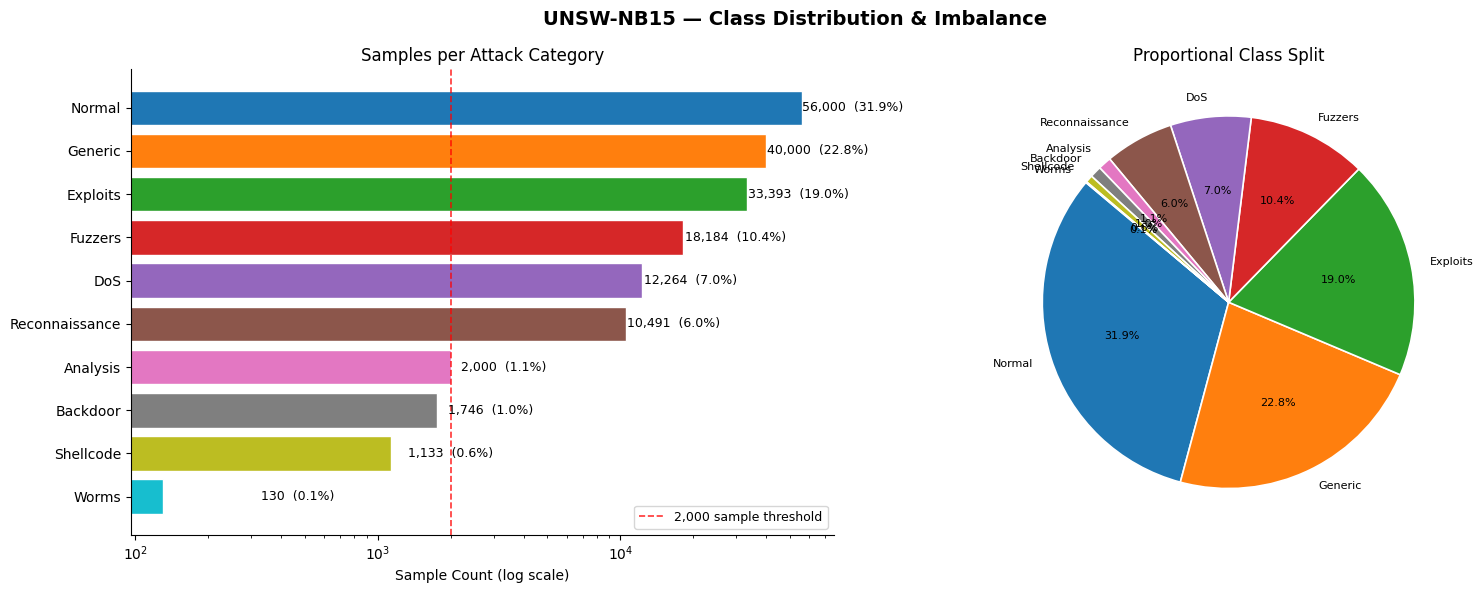


 Class Imbalance Summary
  Normal              56,000  ( 31.9%)
  Generic             40,000  ( 22.8%)
  Exploits            33,393  ( 19.0%)
  Fuzzers             18,184  ( 10.4%)
  DoS                 12,264  (  7.0%)
  Reconnaissance      10,491  (  6.0%)
  Analysis             2,000  (  1.1%)
  Backdoor             1,746  (  1.0%) <-- minority
  Shellcode            1,133  (  0.6%) <-- minority
  Worms                  130  (  0.1%) <-- minority

  Majority class : Normal (56,000)
  Minority class : Worms (130)
  Imbalance ratio: 431:1


In [8]:
import matplotlib.pyplot as plt
import numpy as np

class_counts = training['attack_cat'].value_counts()
total = class_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('UNSW-NB15 — Class Distribution & Imbalance', fontsize=14, fontweight='bold')

# --- Left: horizontal bar chart ---
colors = plt.cm.tab10(np.linspace(0, 1, len(class_counts)))
bars = axes[0].barh(class_counts.index[::-1], class_counts.values[::-1],
                    color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, class_counts.values[::-1]):
    pct = val / total * 100
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9)

axes[0].axvline(2000, color='red', ls='--', lw=1.2, alpha=0.8, label='2,000 sample threshold')
axes[0].set_xscale('log')
axes[0].set_xlabel('Sample Count (log scale)')
axes[0].set_title('Samples per Attack Category')
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# --- Right: pie chart ---
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    textprops={'fontsize': 8}
)
axes[1].set_title('Proportional Class Split')

plt.tight_layout()
plt.show()

# --- Imbalance summary ---
print("\n Class Imbalance Summary")
print("=" * 45)
for cls, cnt in class_counts.items():
    flag = " <-- minority" if cnt < 2000 else ""
    print(f"  {cls:<18} {cnt:>7,}  ({cnt/total*100:5.1f}%){flag}")

print(f"\n  Majority class : {class_counts.idxmax()} ({class_counts.max():,})")
print(f"  Minority class : {class_counts.idxmin()} ({class_counts.min():,})")
print(f"  Imbalance ratio: {class_counts.max() / class_counts.min():.0f}:1")

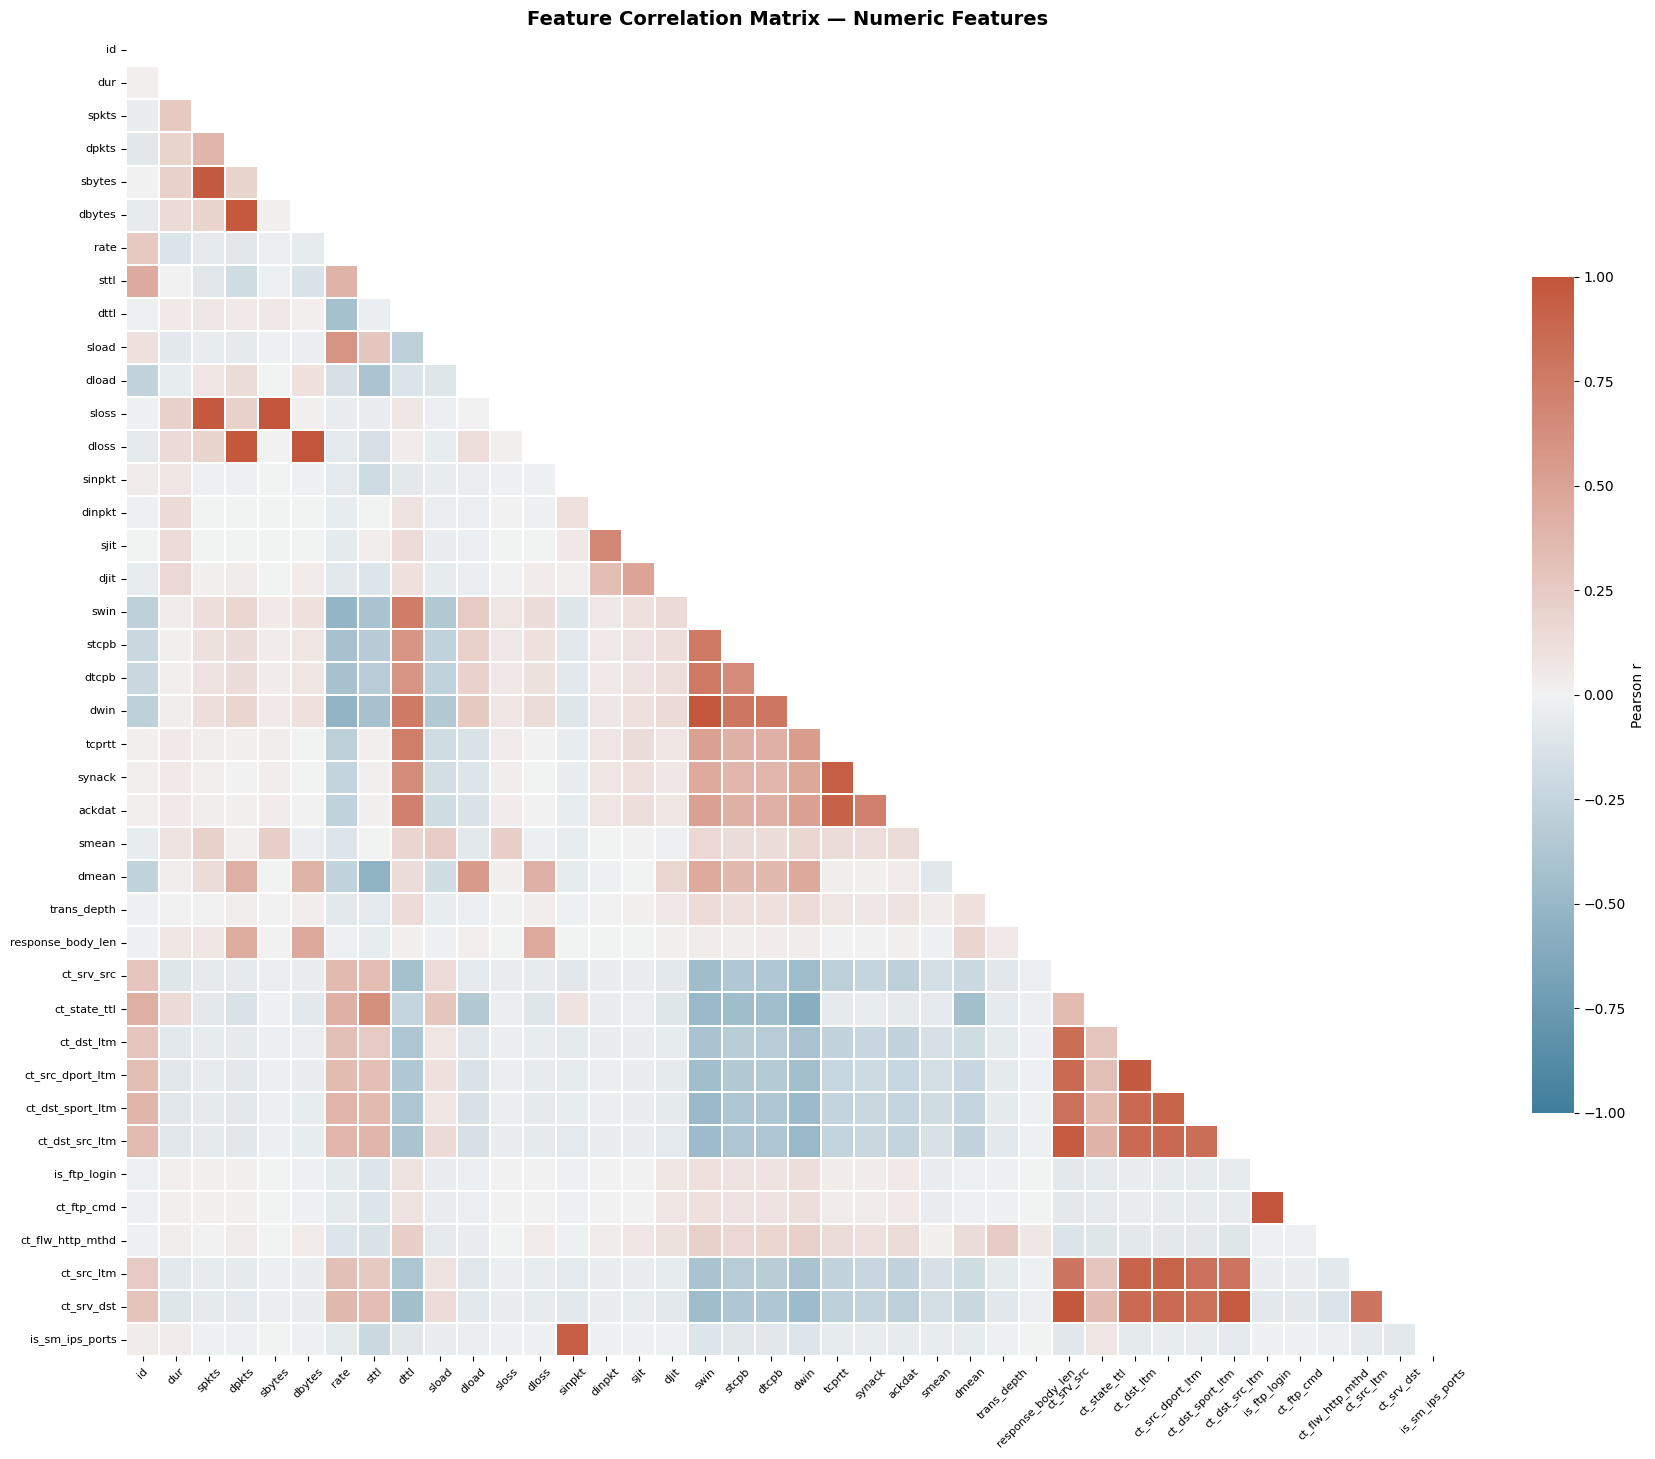

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Numeric features only
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
corr = X_train[numeric_cols].corr()

# --- Plot 1: Full heatmap (lower triangle) ---
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    corr, mask=mask, cmap=cmap,
    vmax=1, vmin=-1, center=0,
    square=True, linewidths=0.2,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
    ax=ax
)
ax.set_title('Feature Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

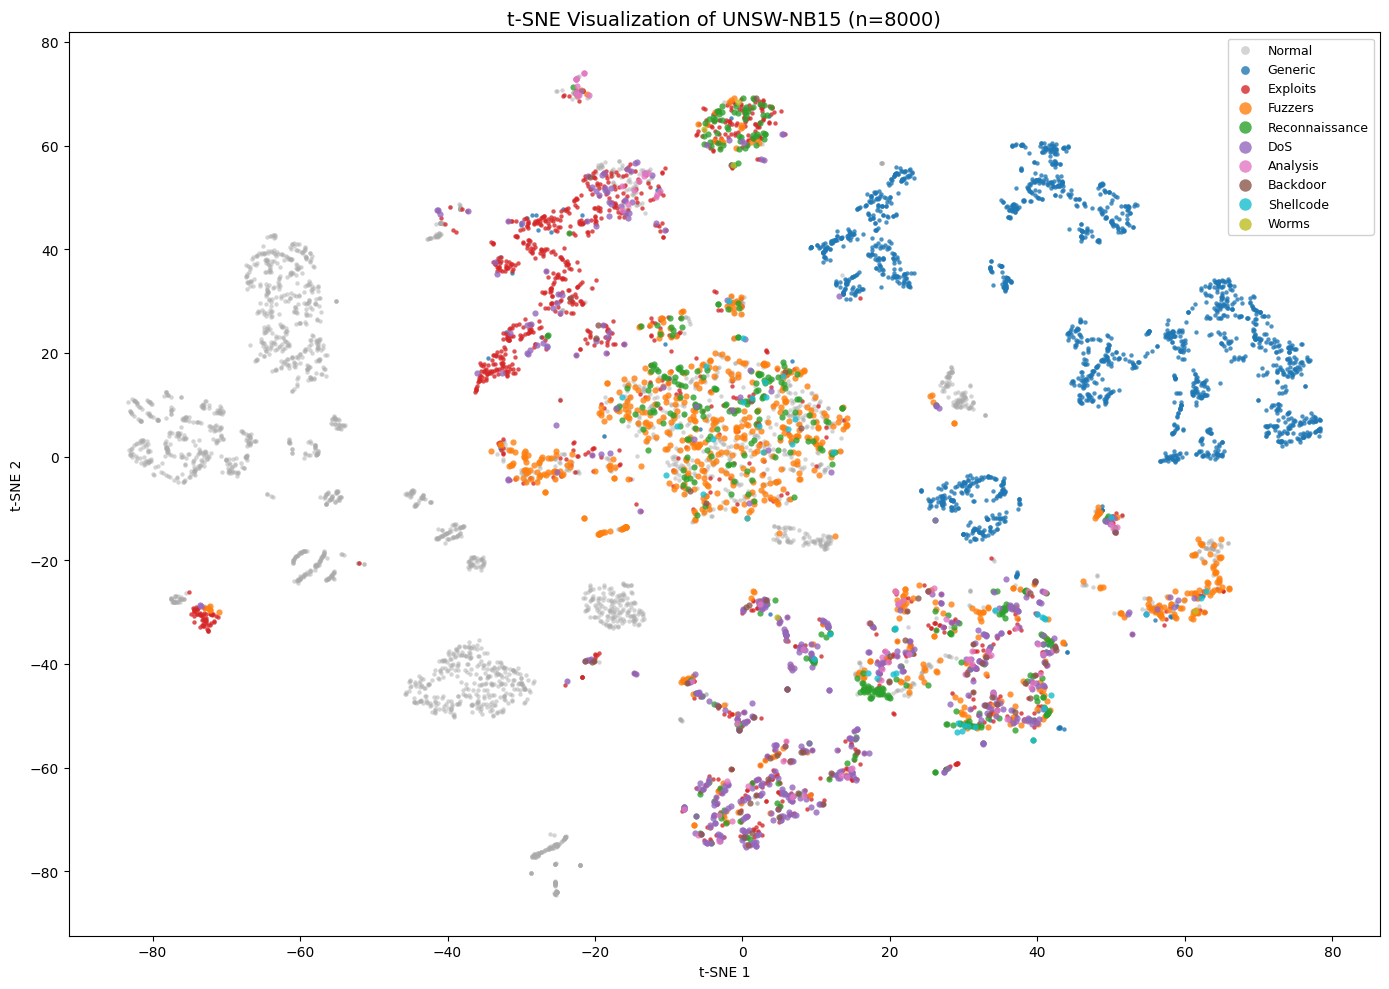

In [42]:
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

# t-SNE is slow on large datasets — sample a manageable subset
# keeping class proportions with stratify
sample_size = 8000
idx = []
for cls in np.unique(y_train):
    cls_idx = np.where(y_train == cls)[0]
    n = max(1, int(sample_size * len(cls_idx) / len(y_train)))
    idx.extend(np.random.choice(cls_idx, n, replace=False))

X_sample = X_train_scaled[idx]
y_sample = y_train[idx]

# Fit t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_embedded = tsne.fit_transform(X_sample)

# Color mapping — Normal gets a distinct neutral color, attacks get vivid colors
color_map = {
    'Normal':         '#aaaaaa',   # grey — stands out as background
    'Generic':        '#1f77b4',   # blue
    'Exploits':       '#d62728',   # red
    'Fuzzers':        '#ff7f0e',   # orange
    'Reconnaissance': '#2ca02c',   # green
    'DoS':            '#9467bd',   # purple
    'Analysis':       '#e377c2',   # pink
    'Backdoor':       '#8c564b',   # brown
    'Shellcode':      '#17becf',   # cyan
    'Worms':          '#bcbd22',   # yellow-green
}

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

for cls_name, color in color_map.items():
    cls_idx = le.transform([cls_name])[0]
    mask = y_sample == cls_idx
    ax.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        c=color,
        label=cls_name,
        alpha=0.5 if cls_name == 'Normal' else 0.8,
        s=10 if cls_name in ['Normal', 'Generic', 'Exploits'] else 20,
        linewidths=0
    )

ax.set_title('t-SNE Visualization of UNSW-NB15 (n=8000)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(
    loc='upper right',
    markerscale=2,
    framealpha=0.9,
    fontsize=9
)
plt.tight_layout()
plt.show()

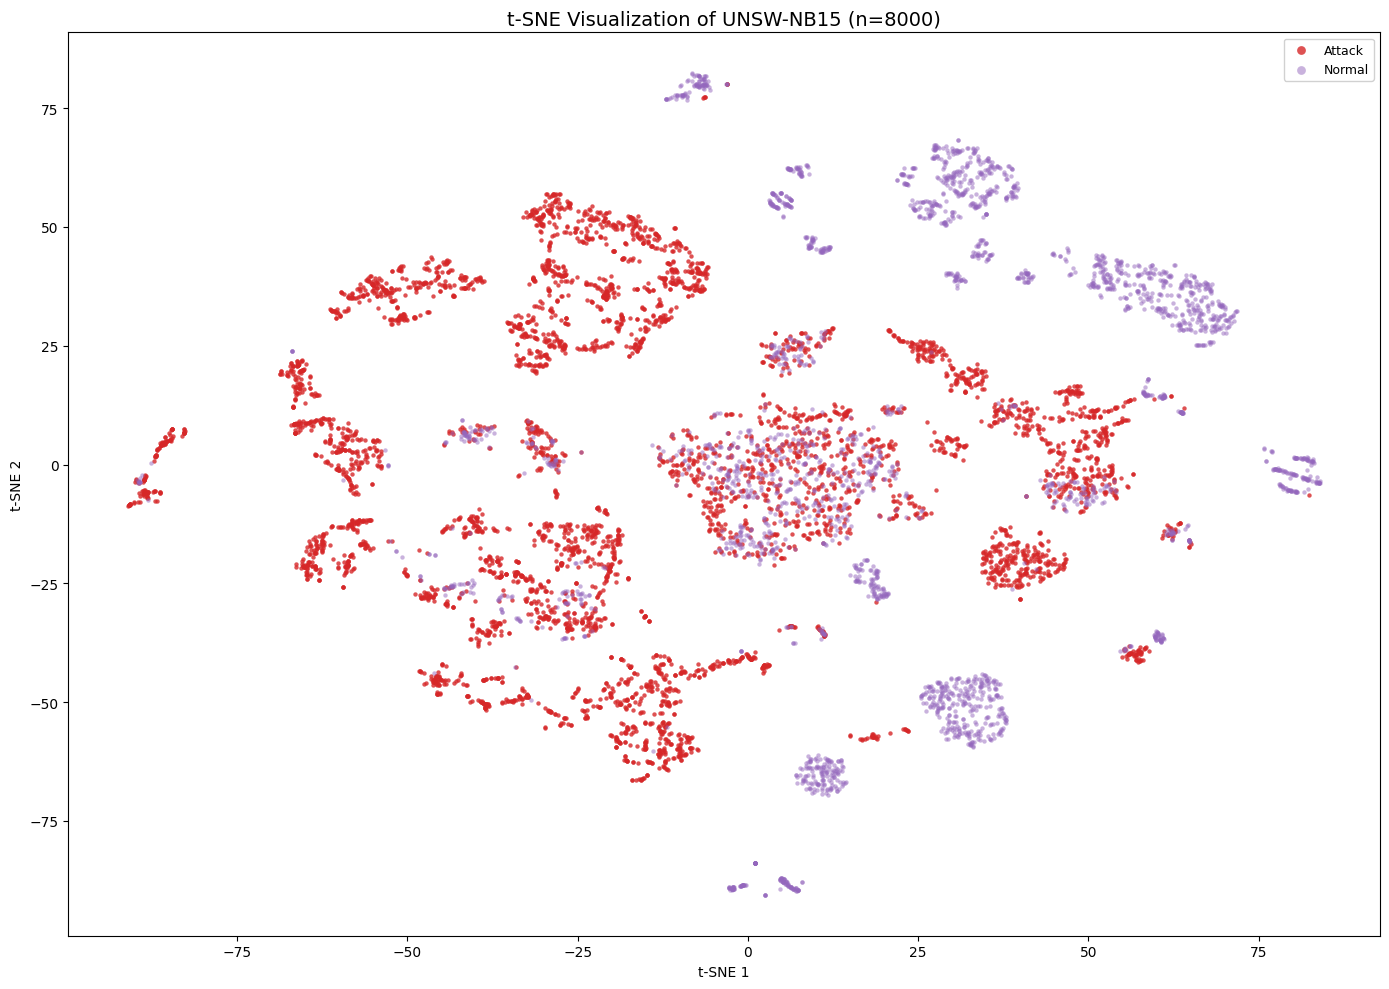

In [47]:
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

# t-SNE is slow on large datasets — sample a manageable subset
# keeping class proportions with stratify
sample_size = 8000
idx = []
for cls in np.unique(y_train):
    cls_idx = np.where(y_train == cls)[0]
    n = max(1, int(sample_size * len(cls_idx) / len(y_train)))
    idx.extend(np.random.choice(cls_idx, n, replace=False))

X_sample = X_train_scaled[idx]
y_sample = y_train[idx]

# Fit t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_embedded = tsne.fit_transform(X_sample)

# Color mapping — Normal gets a distinct neutral color, attacks get vivid colors
color_map = {
    'Normal':         '#9467bd',   # grey — stands out as background
    'Generic':        '#d62728',   # red
    'Exploits':       '#d62728',   # red
    'Fuzzers':        '#d62728',   # orange
    'Reconnaissance': '#d62728',   # green
    'DoS':            '#d62728',   # purple
    'Analysis':       '#d62728',   # pink
    'Backdoor':       '#d62728',   # brown
    'Shellcode':      '#d62728',   # cyan
    'Worms':          '#d62728',   # yellow-green
}

fig, ax = plt.subplots(figsize=(14, 10))

normal_idx = le.transform(['Normal'])[0]
is_normal = y_sample == normal_idx

# Attacks first, Normal on top
ax.scatter(X_embedded[~is_normal, 0], X_embedded[~is_normal, 1],
           c='#d62728', label='Attack', alpha=0.8, s=10, linewidths=0)

ax.scatter(X_embedded[is_normal, 0], X_embedded[is_normal, 1],
           c='#9467bd', label='Normal', alpha=0.5, s=10, linewidths=0)

ax.set_title('t-SNE Visualization of UNSW-NB15 (n=8000)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(loc='upper right', markerscale=2, framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

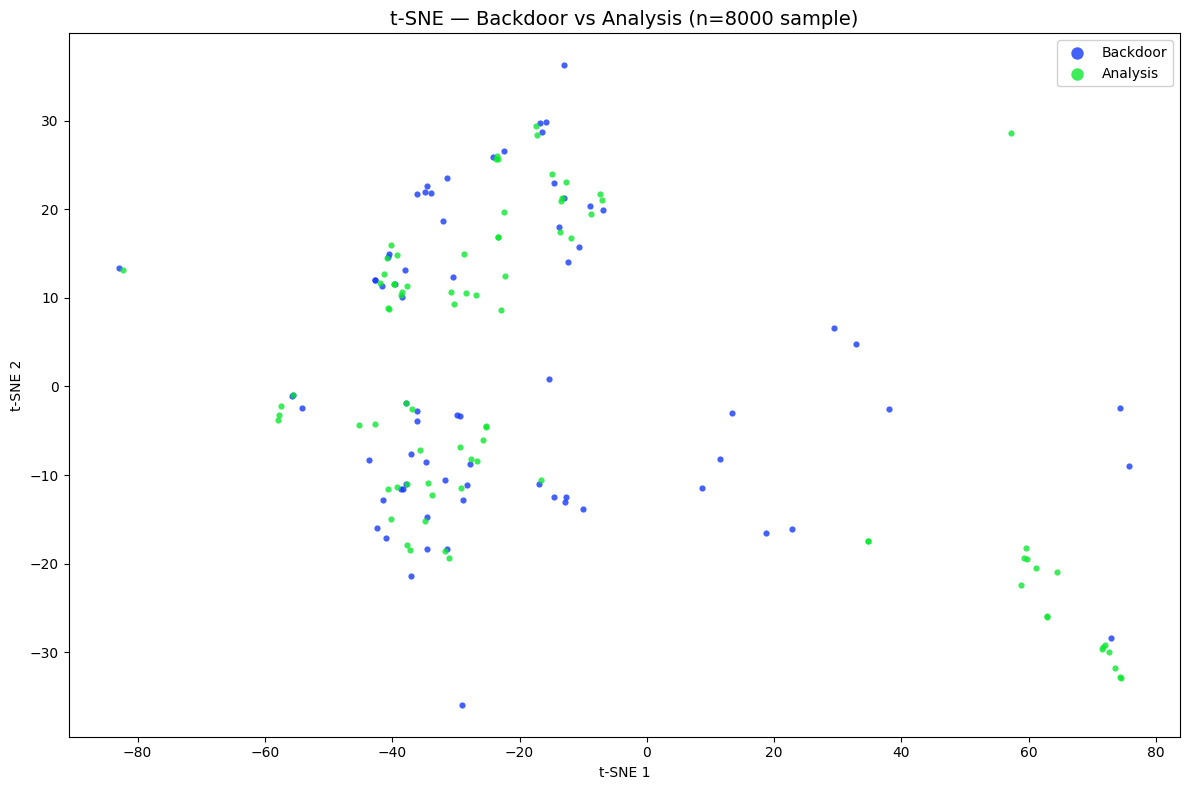

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

# t-SNE is slow on large datasets — sample a manageable subset
# keeping class proportions with stratify
sample_size = 8000
idx = []
for cls in np.unique(y_train):
    cls_idx = np.where(y_train == cls)[0]
    n = max(1, int(sample_size * len(cls_idx) / len(y_train)))
    idx.extend(np.random.choice(cls_idx, n, replace=False))

X_sample = X_train_scaled[idx]
y_sample = y_train[idx]

# Fit t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_embedded = tsne.fit_transform(X_sample)

color_map = {
    'Normal':         "#d62728",   # grey — stands out as background
    'Generic':        '#d62728',   # red
    'Exploits':       '#d62728',   # red
    'Fuzzers':        '#d62728',   # orange
    'Reconnaissance': '#d62728',   # green
    'DoS':            '#d62728',   # purple
    'Analysis':       "#0de832",   # pink
    'Backdoor':       "#153bf9",   # brown
    'Shellcode':      '#d62728',   # cyan
    'Worms':          '#d62728',   # yellow-green
}

fig, ax = plt.subplots(figsize=(12, 8))

# Get indices for only Backdoor and Analysis
target_classes = ['Backdoor', 'Analysis']
target_idx = le.transform(target_classes)

# Filter to only those two classes
mask_targets = np.isin(y_sample, target_idx)
X_filtered = X_embedded[mask_targets]
y_filtered = y_sample[mask_targets]

color_map = {
    'Backdoor': '#153bf9',  # blue
    'Analysis': '#0de832',  # green
}

for cls_name, color in color_map.items():
    cls_idx = le.transform([cls_name])[0]
    mask = y_filtered == cls_idx
    ax.scatter(X_filtered[mask, 0], X_filtered[mask, 1],
               c=color, label=cls_name, alpha=0.8, s=20, linewidths=0)

ax.set_title('t-SNE — Backdoor vs Analysis (n=8000 sample)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(loc='upper right', markerscale=2, framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.show()
plt.show()

In [24]:
sampling_strategy_new = {
    0: 5000,    # Analysis    — currently 1874, small boost
    1: 5000,    # Backdoor    — currently 1630, small boost
    2: 20000,   # DoS
    3: 35000,   # Exploits
    4: 25000,   # Fuzzers
    7: 15000,   # Reconnaissance
    8: 4000,    # Shellcode
}

sampling_strategy_new2 = {
    0: 10000,   # Analysis    — currently at 5000, double it
    1: 10000,   # Backdoor    — currently at 5000, double it
    2: 20000,   # DoS         — keep
    3: 35000,   # Exploits    — keep
    4: 25000,   # Fuzzers     — keep
    7: 15000,   # Reconnaissance — keep
    8: 4000,    # Shellcode   — keep
}



In [25]:
smote = SMOTE(sampling_strategy=sampling_strategy_new2, k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Manually boost weights for the skipped minority classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_smote)

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    objective='multi:softmax',
    num_class=len(le.classes_),
    early_stopping_rounds=30
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    sample_weight=sample_weights,
    eval_set=[(X_test_scaled, y_test)],
)

y_pred = xgb_model.predict(X_test_scaled)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1: {macro_f1:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

[0]	validation_0-mlogloss:2.12456
[1]	validation_0-mlogloss:1.98335
[2]	validation_0-mlogloss:1.86877
[3]	validation_0-mlogloss:1.77027
[4]	validation_0-mlogloss:1.68000
[5]	validation_0-mlogloss:1.60150
[6]	validation_0-mlogloss:1.52949
[7]	validation_0-mlogloss:1.46447
[8]	validation_0-mlogloss:1.40395
[9]	validation_0-mlogloss:1.34916
[10]	validation_0-mlogloss:1.29850
[11]	validation_0-mlogloss:1.25121
[12]	validation_0-mlogloss:1.20767
[13]	validation_0-mlogloss:1.16726
[14]	validation_0-mlogloss:1.13082
[15]	validation_0-mlogloss:1.09560
[16]	validation_0-mlogloss:1.06214
[17]	validation_0-mlogloss:1.03070
[18]	validation_0-mlogloss:1.00160
[19]	validation_0-mlogloss:0.97484
[20]	validation_0-mlogloss:0.94828
[21]	validation_0-mlogloss:0.92380
[22]	validation_0-mlogloss:0.90052
[23]	validation_0-mlogloss:0.87811
[24]	validation_0-mlogloss:0.85679
[25]	validation_0-mlogloss:0.83733
[26]	validation_0-mlogloss:0.81822
[27]	validation_0-mlogloss:0.80041
[28]	validation_0-mlogloss:0.7

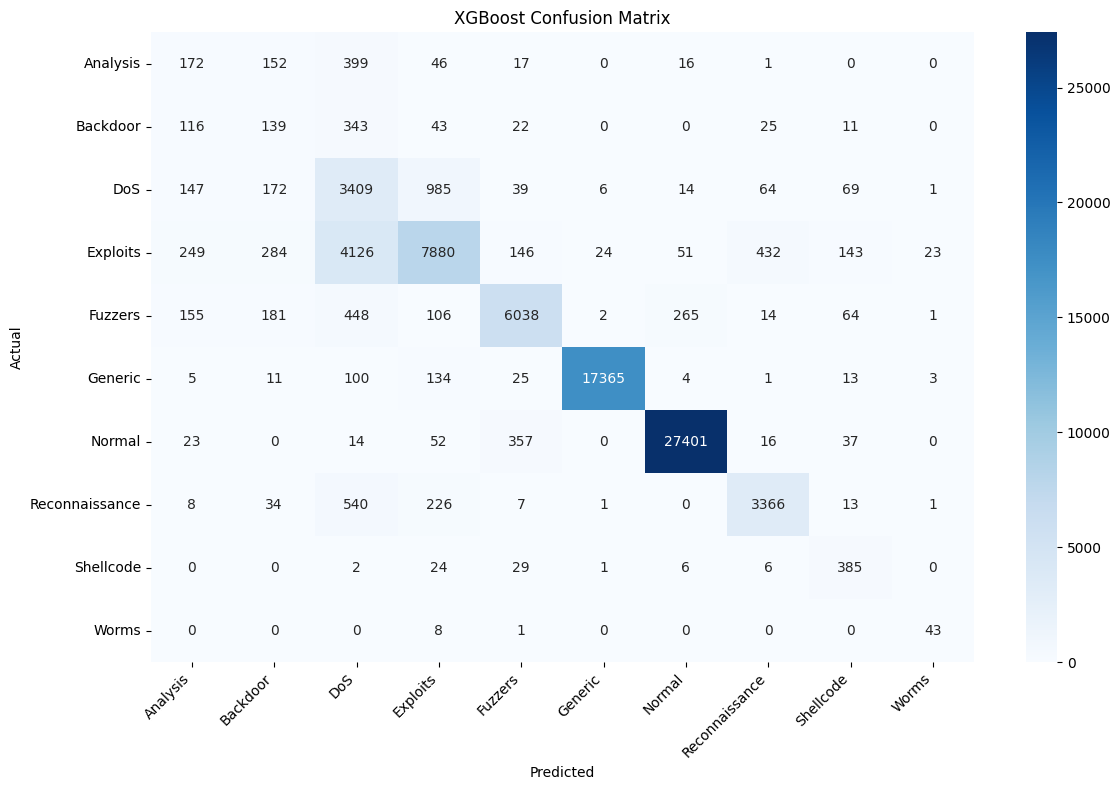

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Showcasing Random Forest and CatBoost performance

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   47.9s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.4min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.2s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    2.9s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:    3.4s finished


0:	learn: 0.4642785	total: 4.2s	remaining: 20m 55s
1:	learn: 0.5110674	total: 7.92s	remaining: 19m 39s
2:	learn: 0.5280654	total: 11.7s	remaining: 19m 14s
3:	learn: 0.5340477	total: 14.3s	remaining: 17m 38s
4:	learn: 0.5080732	total: 17.2s	remaining: 16m 57s
5:	learn: 0.5365712	total: 20.2s	remaining: 16m 29s
6:	learn: 0.5353004	total: 23.2s	remaining: 16m 12s
7:	learn: 0.5375862	total: 26s	remaining: 15m 50s
8:	learn: 0.5432659	total: 28.8s	remaining: 15m 30s
9:	learn: 0.5446474	total: 31.6s	remaining: 15m 15s
10:	learn: 0.5569184	total: 35.7s	remaining: 15m 36s
11:	learn: 0.5508716	total: 40.2s	remaining: 16m 3s
12:	learn: 0.5751465	total: 43.1s	remaining: 15m 52s
13:	learn: 0.5778901	total: 46s	remaining: 15m 40s
14:	learn: 0.5723402	total: 49.1s	remaining: 15m 32s
15:	learn: 0.5704259	total: 52s	remaining: 15m 22s
16:	learn: 0.5751149	total: 54.9s	remaining: 15m 14s
17:	learn: 0.6015379	total: 57.6s	remaining: 15m 2s
18:	learn: 0.6169629	total: 1m	remaining: 14m 56s
19:	learn: 0.61

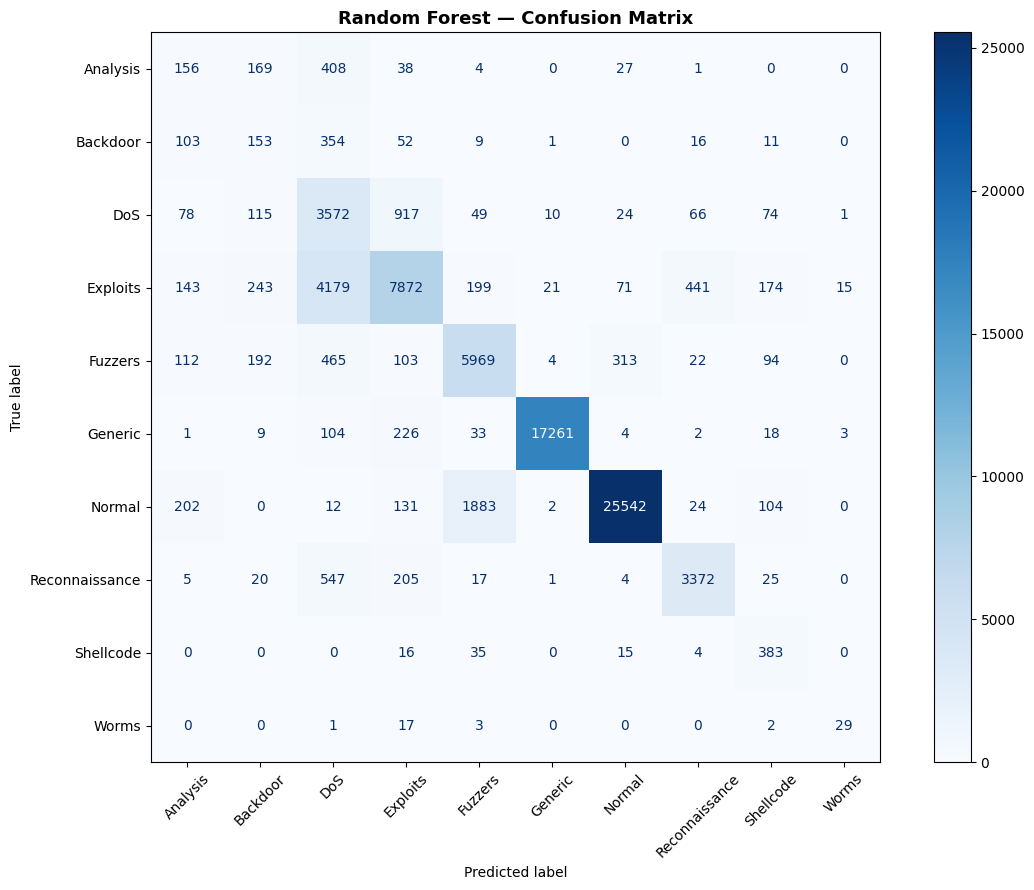


  CatBoost
                precision    recall  f1-score   support

      Analysis       0.11      0.26      0.16       803
      Backdoor       0.15      0.38      0.22       699
           DoS       0.36      0.69      0.47      4906
      Exploits       0.84      0.46      0.59     13358
       Fuzzers       0.61      0.80      0.69      7274
       Generic       1.00      0.97      0.99     17661
        Normal       0.99      0.84      0.91     27900
Reconnaissance       0.83      0.82      0.82      4196
     Shellcode       0.27      0.91      0.42       453
         Worms       0.05      0.96      0.10        52

      accuracy                           0.78     77302
     macro avg       0.52      0.71      0.54     77302
  weighted avg       0.86      0.78      0.80     77302



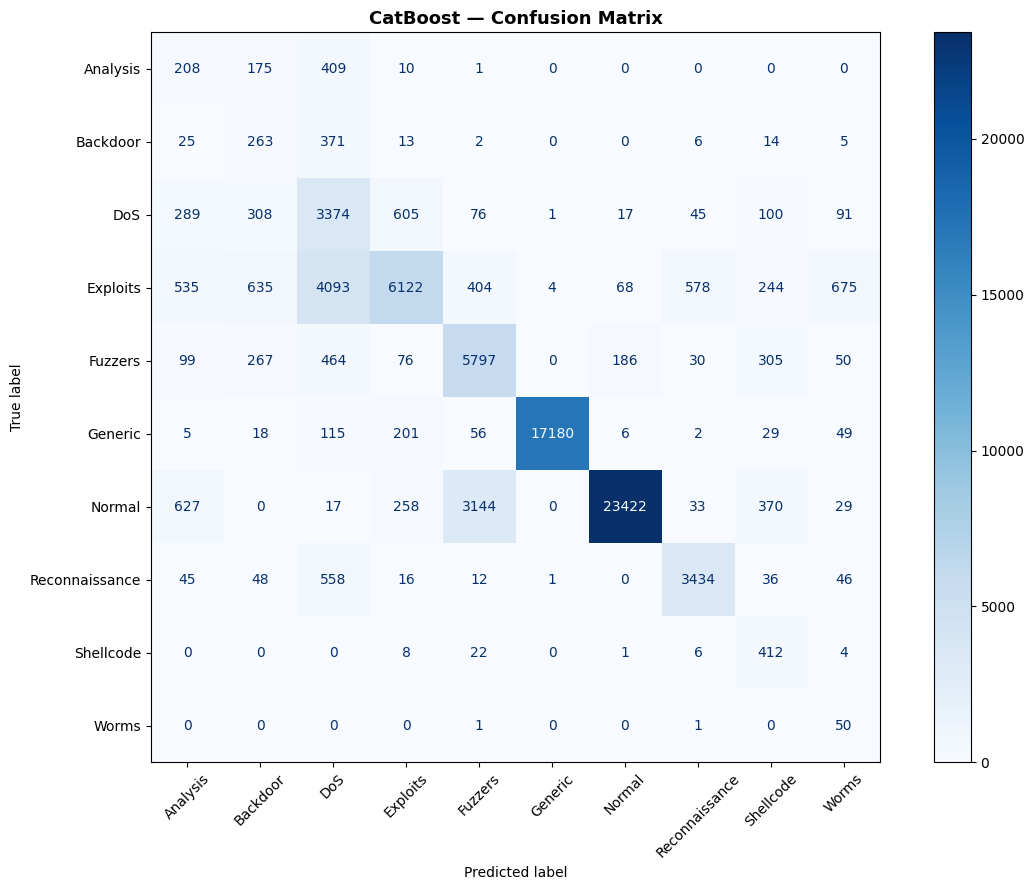

In [31]:
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Random Forest
sample_weights_smote = compute_sample_weight(class_weight='balanced', y=y_train_smote)

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_model.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_model.predict(X_test_scaled)

# CatBoost
# Convert X_train_smote back to DataFrame so CatBoost can identify cat_features by name
X_train_smote_df = pd.DataFrame(X_train_smote, columns=X_train_enc.columns)
X_test_cat = pd.DataFrame(X_test_scaled, columns=X_train_enc.columns)

for col in categorical_features:
    X_train_smote_df[col] = X_train_smote_df[col].astype(str).replace('nan', 'missing')
    X_test_cat[col]       = X_test_cat[col].astype(str).replace('nan', 'missing')

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    auto_class_weights='Balanced',
    od_type='Iter',
    od_wait=50,
    random_seed=42,
    verbose=1
)

cat_model.fit(
    X_train_smote_df, y_train_smote,
    cat_features=categorical_features
)
y_pred_cat = cat_model.predict(X_test_cat).flatten()



def evaluate_model(name, y_true, y_pred):
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    fig, ax = plt.subplots(figsize=(12, 9))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(
        cmap='Blues', ax=ax, xticks_rotation=45
    )
    ax.set_title(f'{name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return f1_score(y_true, y_pred, average='macro')

rf_f1  = evaluate_model('Random Forest', y_test, y_pred_rf)
cat_f1 = evaluate_model('CatBoost',      y_test, y_pred_cat)

## Binary Classification Normal vs Attack connections

In [ ]:
from sklearn.model_selection import train_test_split

# Use random 70/30 split
full_data = pd.concat([training, testing], ignore_index=True)

X_full = full_data.drop(columns=['attack_cat', 'label'])
y_full = full_data['label']




X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)

# Encode + Scale
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()
X_train_enc[categorical_features] = oe.fit_transform(X_train[categorical_features])
X_test_enc[categorical_features]  = oe.transform(X_test[categorical_features])


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

print("Training Set (1 = Attack 0 = Normal):")
print(y_train.value_counts())
print("Training Set (1 = Attack 0 = Normal):")
print(y_test.value_counts())



Training Set (1 = Attack 0 = Normal):
label
1    115271
0     65100
Name: count, dtype: int64
Training Set (1 = Attack 0 = Normal):
label
1    49402
0    27900
Name: count, dtype: int64


In [54]:
# smote = SMOTE(sampling_strategy=sampling_strategy_phase2, k_neighbors=5, random_state=42)
# X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Manually boost weights for the skipped minority classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    objective='binary:logistic',
    early_stopping_rounds=30
)

xgb_model.fit(
    X_train_scaled, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test_scaled, y_test)],
)

y_pred = xgb_model.predict(X_test_scaled)
f1 = f1_score(y_test, y_pred, average='binary')
print(f"F1 Score: {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

[0]	validation_0-logloss:0.64919
[1]	validation_0-logloss:0.60931
[2]	validation_0-logloss:0.57633
[3]	validation_0-logloss:0.54585
[4]	validation_0-logloss:0.51461
[5]	validation_0-logloss:0.48700
[6]	validation_0-logloss:0.46027
[7]	validation_0-logloss:0.43851
[8]	validation_0-logloss:0.41549
[9]	validation_0-logloss:0.39521
[10]	validation_0-logloss:0.37557
[11]	validation_0-logloss:0.35705
[12]	validation_0-logloss:0.34017
[13]	validation_0-logloss:0.32382
[14]	validation_0-logloss:0.30863
[15]	validation_0-logloss:0.29446
[16]	validation_0-logloss:0.28167
[17]	validation_0-logloss:0.27069
[18]	validation_0-logloss:0.25894
[19]	validation_0-logloss:0.24787
[20]	validation_0-logloss:0.23870
[21]	validation_0-logloss:0.23005
[22]	validation_0-logloss:0.22197
[23]	validation_0-logloss:0.21298
[24]	validation_0-logloss:0.20468
[25]	validation_0-logloss:0.19692
[26]	validation_0-logloss:0.19065
[27]	validation_0-logloss:0.18346
[28]	validation_0-logloss:0.17717
[29]	validation_0-loglos

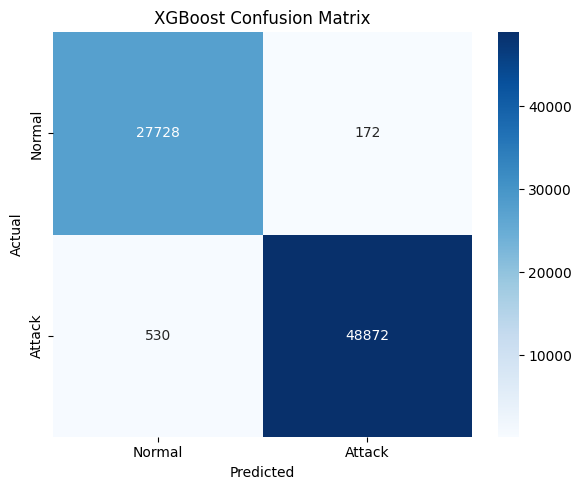

In [55]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()